Fully classical GAN used for comparison with hybrid models. Trained for 50, 30, and 10 epochs. 

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import matplotlib.pyplot as plt

In [ ]:

latent_dim = 100
batch_size = 128
lr = 2e-4
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_ds = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # input: (latent_dim,)
            nn.Linear(latent_dim, 256*7*7),
            nn.BatchNorm1d(256*7*7),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 7, 7)),           # → (256,7,7)
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # → (128,14,14)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 1, 4, 2, 1),    # → (1,28,28)
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),  # → (64,14,14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),# → (128,7,7)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128*7*7, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

G = Generator().to(device)
D = Discriminator().to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

for epoch in range(epochs):
    for real_imgs, _ in loader:
        real_imgs = real_imgs.to(device)
        bsz = real_imgs.size(0)
        z = torch.randn(bsz, latent_dim, device=device)
        fake_imgs = G(z)
        real_labels = torch.ones(bsz, 1, device=device)
        fake_labels = torch.zeros(bsz, 1, device=device)

        D_real = D(real_imgs)
        D_fake = D(fake_imgs.detach())
        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        D_fake_for_G = D(fake_imgs)
        loss_G = criterion(D_fake_for_G, real_labels)
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    print(f"Epoch {epoch+1}/{epochs}  Loss_D: {loss_D:.4f}  Loss_G: {loss_G:.4f}")


Epoch 1/50  Loss_D: 0.0022  Loss_G: 6.7969
Epoch 2/50  Loss_D: 0.3968  Loss_G: 1.7919
Epoch 3/50  Loss_D: 0.6504  Loss_G: 2.8008
Epoch 4/50  Loss_D: 0.3497  Loss_G: 3.9540
Epoch 5/50  Loss_D: 0.2700  Loss_G: 2.3280
Epoch 6/50  Loss_D: 0.4133  Loss_G: 2.0589
Epoch 7/50  Loss_D: 0.2448  Loss_G: 3.1377
Epoch 8/50  Loss_D: 0.6790  Loss_G: 4.0990
Epoch 9/50  Loss_D: 0.3433  Loss_G: 2.2821
Epoch 10/50  Loss_D: 0.2764  Loss_G: 3.2684
Epoch 11/50  Loss_D: 0.2914  Loss_G: 2.3112
Epoch 12/50  Loss_D: 0.3338  Loss_G: 3.0157
Epoch 13/50  Loss_D: 0.5350  Loss_G: 2.4936
Epoch 14/50  Loss_D: 0.3991  Loss_G: 2.9629
Epoch 15/50  Loss_D: 0.2753  Loss_G: 2.5798
Epoch 16/50  Loss_D: 0.4763  Loss_G: 1.3939
Epoch 17/50  Loss_D: 0.4602  Loss_G: 1.6767
Epoch 18/50  Loss_D: 0.2464  Loss_G: 2.9999
Epoch 19/50  Loss_D: 0.2172  Loss_G: 2.6715
Epoch 20/50  Loss_D: 0.2512  Loss_G: 3.4255
Epoch 21/50  Loss_D: 0.2651  Loss_G: 2.7052
Epoch 22/50  Loss_D: 0.6731  Loss_G: 4.9142
Epoch 23/50  Loss_D: 0.3552  Loss_G: 1.94

Training MNIST classifier for mode-collapse…
  Epoch 1/3  acc = 0.9363
  Epoch 2/3  acc = 0.9832
  Epoch 3/3  acc = 0.9885
Classifier ready.

FID:                59.47
Inception Score:    1.06 ± 0.02
Mode Collapse Rate: 0.0%
PSNR:               8.96
SSIM:               0.221


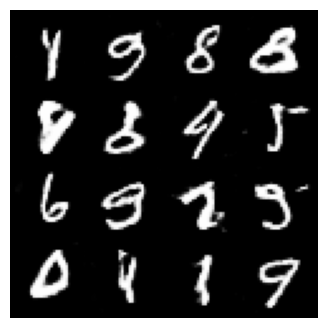

In [ ]:

cla_batch = 64
cla_transform = transforms.ToTensor()  # [0,1]
cla_train_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=cla_transform),
    batch_size=cla_batch, shuffle=True
)

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),  # 28×28 → 28×28
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 14×14
            nn.Conv2d(32, 64, 3, 1, 1), # → 14×14
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 7×7
            nn.Flatten(),               # → 64*7*7
            nn.Linear(64*7*7, 128),
            nn.ReLU(True),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

classifier = MNISTClassifier().to(device)
opt_C = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_C = nn.CrossEntropyLoss()

for epoch in range(3):
    classifier.train()
    total, correct = 0, 0
    for imgs, labels in cla_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = classifier(imgs)
        loss = criterion_C(logits, labels)
        opt_C.zero_grad(); loss.backward(); opt_C.step()

        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    acc = correct / total
    print(f"Classifier Epoch {epoch+1}/3 – Accuracy: {acc:.4f}")


def compute_fid(real_imgs: torch.Tensor, fake_imgs: torch.Tensor, device=device) -> float:
    real_uint8 = (real_imgs * 255).to(torch.uint8)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    fid = FrechetInceptionDistance(feature=2048).to(device)
    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    return fid.compute().item()

def compute_inception_score(fake_imgs: torch.Tensor, device=device):
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    is_metric = InceptionScore(feature=2048).to(device)
    is_metric.update(fake_uint8)
    mean, std = is_metric.compute()
    return mean.item(), std.item()

def compute_mode_collapse(model, classifier, n_images=10000, device=device) -> float:
    model.eval(); classifier.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake = (model(z) + 1) / 2.0
        preds = classifier(fake).argmax(dim=1).cpu().tolist()
    seen = len(set(preds))
    return (1 - seen / 10.0) * 100 

def compute_psnr_ssim(real_images: torch.Tensor, fake_images: torch.Tensor):
    real_np = real_images.cpu().numpy()
    fake_np = fake_images.cpu().numpy()
    psnr_vals, ssim_vals = [], []
    for r, f in zip(real_np, fake_np):
        r2, f2 = r.squeeze(), f.squeeze()
        psnr_vals.append(psnr(r2, f2, data_range=1.0))
        ssim_vals.append(ssim(r2, f2, data_range=1.0))
    return sum(psnr_vals)/len(psnr_vals), sum(ssim_vals)/len(ssim_vals)


G.eval()

real_batch, _ = next(iter(train_loader))
real_small = (real_batch.to(device) + 1) / 2            # [0,1], [B,1,28,28]
real_for_fid = real_small.repeat(1,3,1,1)               # [B,3,28,28]
real_for_fid = F.interpolate(real_for_fid, size=(299,299), mode='bilinear')

with torch.no_grad():
    z = torch.randn(real_for_fid.size(0), latent_dim, device=device)
    fake_small = G(z).cpu().clamp(-1,1).add(1).div(2)   # [0,1], [B,1,28,28]
fake_for_fid = fake_small.repeat(1,3,1,1)
fake_for_fid = F.interpolate(fake_for_fid, size=(299,299), mode='bilinear')

fid_val = compute_fid(real_for_fid, fake_for_fid, device)
print(f"FID:                 {fid_val:.2f}")

is_mean, is_std = compute_inception_score(fake_for_fid, device)
print(f"Inception Score:     {is_mean:.2f} ± {is_std:.2f}")

mode_rate = compute_mode_collapse(G, classifier, device=device)
print(f"Mode Collapse Rate:  {mode_rate:.1f}%")

psnr_val, ssim_val = compute_psnr_ssim(real_small.cpu(), fake_small)
print(f"PSNR:                {psnr_val:.2f}")
print(f"SSIM:                {ssim_val:.3f}")

with torch.no_grad():
    z2 = torch.randn(16, latent_dim, device=device)
    samples = (G(z2).cpu().clamp(-1,1).add(1).div(2))   # [0,1], [16,1,28,28]
grid = make_grid(samples, nrow=4)
plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()


In [ ]:

latent_dim = 100
batch_size = 128
lr = 2e-4
epochs = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_ds = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # input: (latent_dim,)
            nn.Linear(latent_dim, 256*7*7),
            nn.BatchNorm1d(256*7*7),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 7, 7)),           # → (256,7,7)
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # → (128,14,14)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 1, 4, 2, 1),    # → (1,28,28)
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),  # → (64,14,14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),# → (128,7,7)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128*7*7, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

G = Generator().to(device)
D = Discriminator().to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

for epoch in range(epochs):
    for real_imgs, _ in loader:
        real_imgs = real_imgs.to(device)
        bsz = real_imgs.size(0)
        z = torch.randn(bsz, latent_dim, device=device)
        fake_imgs = G(z)
        real_labels = torch.ones(bsz, 1, device=device)
        fake_labels = torch.zeros(bsz, 1, device=device)

        D_real = D(real_imgs)
        D_fake = D(fake_imgs.detach())
        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        D_fake_for_G = D(fake_imgs)
        loss_G = criterion(D_fake_for_G, real_labels)
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    print(f"Epoch {epoch+1}/{epochs}  Loss_D: {loss_D:.4f}  Loss_G: {loss_G:.4f}")


Epoch 1/30  Loss_D: 0.0023  Loss_G: 6.7151
Epoch 2/30  Loss_D: 0.0002  Loss_G: 9.1355
Epoch 3/30  Loss_D: 0.0001  Loss_G: 9.8773
Epoch 4/30  Loss_D: 0.5635  Loss_G: 1.3215
Epoch 5/30  Loss_D: 0.4291  Loss_G: 2.3396
Epoch 6/30  Loss_D: 0.5212  Loss_G: 1.2393
Epoch 7/30  Loss_D: 0.4023  Loss_G: 1.6083
Epoch 8/30  Loss_D: 0.5794  Loss_G: 2.9252
Epoch 9/30  Loss_D: 0.4240  Loss_G: 2.0134
Epoch 10/30  Loss_D: 0.4152  Loss_G: 2.6766
Epoch 11/30  Loss_D: 0.3304  Loss_G: 2.4297
Epoch 12/30  Loss_D: 0.3375  Loss_G: 2.3626
Epoch 13/30  Loss_D: 0.4841  Loss_G: 2.3608
Epoch 14/30  Loss_D: 0.4014  Loss_G: 3.0220
Epoch 15/30  Loss_D: 0.3167  Loss_G: 3.2701
Epoch 16/30  Loss_D: 0.4418  Loss_G: 1.7654
Epoch 17/30  Loss_D: 0.4712  Loss_G: 2.3907
Epoch 18/30  Loss_D: 0.3690  Loss_G: 1.7185
Epoch 19/30  Loss_D: 0.5387  Loss_G: 1.4683
Epoch 20/30  Loss_D: 0.3836  Loss_G: 2.3758
Epoch 21/30  Loss_D: 0.3477  Loss_G: 2.2574
Epoch 22/30  Loss_D: 0.4329  Loss_G: 2.9357
Epoch 23/30  Loss_D: 0.4851  Loss_G: 1.85

Training MNIST classifier for mode-collapse…
  Epoch 1/3  acc = 0.9324
  Epoch 2/3  acc = 0.9829
  Epoch 3/3  acc = 0.9873
Classifier ready.

FID:                67.73
Inception Score:    1.07 ± 0.03
Mode Collapse Rate: 0.0%
PSNR:               8.68
SSIM:               0.192


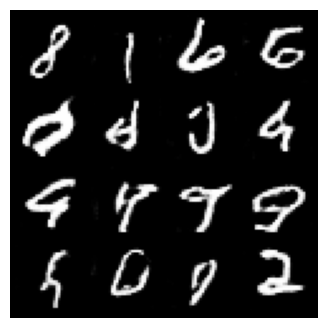

In [ ]:

cla_batch = 64
cla_transform = transforms.ToTensor()  # [0,1]
cla_train_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=cla_transform),
    batch_size=cla_batch, shuffle=True
)

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),  # 28×28 → 28×28
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 14×14
            nn.Conv2d(32, 64, 3, 1, 1), # → 14×14
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 7×7
            nn.Flatten(),               # → 64*7*7
            nn.Linear(64*7*7, 128),
            nn.ReLU(True),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

classifier = MNISTClassifier().to(device)
opt_C = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_C = nn.CrossEntropyLoss()

for epoch in range(3):
    classifier.train()
    total, correct = 0, 0
    for imgs, labels in cla_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = classifier(imgs)
        loss = criterion_C(logits, labels)
        opt_C.zero_grad(); loss.backward(); opt_C.step()

        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    acc = correct / total
    print(f"Classifier Epoch {epoch+1}/3 – Accuracy: {acc:.4f}")


def compute_fid(real_imgs: torch.Tensor, fake_imgs: torch.Tensor, device=device) -> float:
    real_uint8 = (real_imgs * 255).to(torch.uint8)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    fid = FrechetInceptionDistance(feature=2048).to(device)
    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    return fid.compute().item()

def compute_inception_score(fake_imgs: torch.Tensor, device=device):
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    is_metric = InceptionScore(feature=2048).to(device)
    is_metric.update(fake_uint8)
    mean, std = is_metric.compute()
    return mean.item(), std.item()

def compute_mode_collapse(model, classifier, n_images=10000, device=device) -> float:
    model.eval(); classifier.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake = (model(z) + 1) / 2.0
        preds = classifier(fake).argmax(dim=1).cpu().tolist()
    seen = len(set(preds))
    return (1 - seen / 10.0) * 100 

def compute_psnr_ssim(real_images: torch.Tensor, fake_images: torch.Tensor):
    real_np = real_images.cpu().numpy()
    fake_np = fake_images.cpu().numpy()
    psnr_vals, ssim_vals = [], []
    for r, f in zip(real_np, fake_np):
        r2, f2 = r.squeeze(), f.squeeze()
        psnr_vals.append(psnr(r2, f2, data_range=1.0))
        ssim_vals.append(ssim(r2, f2, data_range=1.0))
    return sum(psnr_vals)/len(psnr_vals), sum(ssim_vals)/len(ssim_vals)


G.eval()

real_batch, _ = next(iter(train_loader))
real_small = (real_batch.to(device) + 1) / 2            # [0,1], [B,1,28,28]
real_for_fid = real_small.repeat(1,3,1,1)               # [B,3,28,28]
real_for_fid = F.interpolate(real_for_fid, size=(299,299), mode='bilinear')

with torch.no_grad():
    z = torch.randn(real_for_fid.size(0), latent_dim, device=device)
    fake_small = G(z).cpu().clamp(-1,1).add(1).div(2)   # [0,1], [B,1,28,28]
fake_for_fid = fake_small.repeat(1,3,1,1)
fake_for_fid = F.interpolate(fake_for_fid, size=(299,299), mode='bilinear')

fid_val = compute_fid(real_for_fid, fake_for_fid, device)
print(f"FID:                 {fid_val:.2f}")

is_mean, is_std = compute_inception_score(fake_for_fid, device)
print(f"Inception Score:     {is_mean:.2f} ± {is_std:.2f}")

mode_rate = compute_mode_collapse(G, classifier, device=device)
print(f"Mode Collapse Rate:  {mode_rate:.1f}%")

psnr_val, ssim_val = compute_psnr_ssim(real_small.cpu(), fake_small)
print(f"PSNR:                {psnr_val:.2f}")
print(f"SSIM:                {ssim_val:.3f}")

with torch.no_grad():
    z2 = torch.randn(16, latent_dim, device=device)
    samples = (G(z2).cpu().clamp(-1,1).add(1).div(2))   # [0,1], [16,1,28,28]
grid = make_grid(samples, nrow=4)
plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()


In [ ]:

latent_dim = 100
batch_size = 128
lr = 2e-4
epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_ds = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # input: (latent_dim,)
            nn.Linear(latent_dim, 256*7*7),
            nn.BatchNorm1d(256*7*7),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 7, 7)),           # → (256,7,7)
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # → (128,14,14)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 1, 4, 2, 1),    # → (1,28,28)
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),  # → (64,14,14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),# → (128,7,7)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128*7*7, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

G = Generator().to(device)
D = Discriminator().to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

for epoch in range(epochs):
    for real_imgs, _ in loader:
        real_imgs = real_imgs.to(device)
        bsz = real_imgs.size(0)
        z = torch.randn(bsz, latent_dim, device=device)
        fake_imgs = G(z)
        real_labels = torch.ones(bsz, 1, device=device)
        fake_labels = torch.zeros(bsz, 1, device=device)

        D_real = D(real_imgs)
        D_fake = D(fake_imgs.detach())
        loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        D_fake_for_G = D(fake_imgs)
        loss_G = criterion(D_fake_for_G, real_labels)
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    print(f"Epoch {epoch+1}/{epochs}  Loss_D: {loss_D:.4f}  Loss_G: {loss_G:.4f}")


Epoch 1/10  Loss_D: 0.0006  Loss_G: 7.8902
Epoch 2/10  Loss_D: 0.3350  Loss_G: 2.1792
Epoch 3/10  Loss_D: 0.3266  Loss_G: 2.0048
Epoch 4/10  Loss_D: 0.3411  Loss_G: 2.0146
Epoch 5/10  Loss_D: 0.3413  Loss_G: 2.3569
Epoch 6/10  Loss_D: 0.2688  Loss_G: 2.4187
Epoch 7/10  Loss_D: 0.3225  Loss_G: 2.3763
Epoch 8/10  Loss_D: 0.6524  Loss_G: 0.8758
Epoch 9/10  Loss_D: 0.4351  Loss_G: 1.4022
Epoch 10/10  Loss_D: 0.2711  Loss_G: 2.6124


Training MNIST classifier for mode-collapse…
  Epoch 1/3  acc = 0.9300
  Epoch 2/3  acc = 0.9817
  Epoch 3/3  acc = 0.9880
Classifier ready.

FID:                76.53
Inception Score:    1.07 ± 0.02
Mode Collapse Rate: 0.0%
PSNR:               9.09
SSIM:               0.233


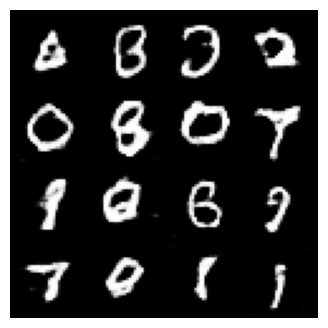

In [ ]:

cla_batch = 64
cla_transform = transforms.ToTensor()  # [0,1]
cla_train_loader = DataLoader(
    datasets.MNIST("./data", train=True, download=True, transform=cla_transform),
    batch_size=cla_batch, shuffle=True
)

class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, 1),  # 28×28 → 28×28
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 14×14
            nn.Conv2d(32, 64, 3, 1, 1), # → 14×14
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),         # → 7×7
            nn.Flatten(),               # → 64*7*7
            nn.Linear(64*7*7, 128),
            nn.ReLU(True),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

classifier = MNISTClassifier().to(device)
opt_C = optim.Adam(classifier.parameters(), lr=1e-3)
criterion_C = nn.CrossEntropyLoss()

for epoch in range(3):
    classifier.train()
    total, correct = 0, 0
    for imgs, labels in cla_train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = classifier(imgs)
        loss = criterion_C(logits, labels)
        opt_C.zero_grad(); loss.backward(); opt_C.step()

        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    acc = correct / total
    print(f"Classifier Epoch {epoch+1}/3 – Accuracy: {acc:.4f}")


def compute_fid(real_imgs: torch.Tensor, fake_imgs: torch.Tensor, device=device) -> float:
    real_uint8 = (real_imgs * 255).to(torch.uint8)
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    fid = FrechetInceptionDistance(feature=2048).to(device)
    fid.update(real_uint8, real=True)
    fid.update(fake_uint8, real=False)
    return fid.compute().item()

def compute_inception_score(fake_imgs: torch.Tensor, device=device):
    fake_uint8 = (fake_imgs * 255).to(torch.uint8)
    is_metric = InceptionScore(feature=2048).to(device)
    is_metric.update(fake_uint8)
    mean, std = is_metric.compute()
    return mean.item(), std.item()

def compute_mode_collapse(model, classifier, n_images=10000, device=device) -> float:
    model.eval(); classifier.eval()
    with torch.no_grad():
        z = torch.randn(n_images, latent_dim, device=device)
        fake = (model(z) + 1) / 2.0
        preds = classifier(fake).argmax(dim=1).cpu().tolist()
    seen = len(set(preds))
    return (1 - seen / 10.0) * 100 

def compute_psnr_ssim(real_images: torch.Tensor, fake_images: torch.Tensor):
    real_np = real_images.cpu().numpy()
    fake_np = fake_images.cpu().numpy()
    psnr_vals, ssim_vals = [], []
    for r, f in zip(real_np, fake_np):
        r2, f2 = r.squeeze(), f.squeeze()
        psnr_vals.append(psnr(r2, f2, data_range=1.0))
        ssim_vals.append(ssim(r2, f2, data_range=1.0))
    return sum(psnr_vals)/len(psnr_vals), sum(ssim_vals)/len(ssim_vals)


G.eval()

real_batch, _ = next(iter(train_loader))
real_small = (real_batch.to(device) + 1) / 2            # [0,1], [B,1,28,28]
real_for_fid = real_small.repeat(1,3,1,1)               # [B,3,28,28]
real_for_fid = F.interpolate(real_for_fid, size=(299,299), mode='bilinear')

with torch.no_grad():
    z = torch.randn(real_for_fid.size(0), latent_dim, device=device)
    fake_small = G(z).cpu().clamp(-1,1).add(1).div(2)   # [0,1], [B,1,28,28]
fake_for_fid = fake_small.repeat(1,3,1,1)
fake_for_fid = F.interpolate(fake_for_fid, size=(299,299), mode='bilinear')

fid_val = compute_fid(real_for_fid, fake_for_fid, device)
print(f"FID:                 {fid_val:.2f}")

is_mean, is_std = compute_inception_score(fake_for_fid, device)
print(f"Inception Score:     {is_mean:.2f} ± {is_std:.2f}")

mode_rate = compute_mode_collapse(G, classifier, device=device)
print(f"Mode Collapse Rate:  {mode_rate:.1f}%")

psnr_val, ssim_val = compute_psnr_ssim(real_small.cpu(), fake_small)
print(f"PSNR:                {psnr_val:.2f}")
print(f"SSIM:                {ssim_val:.3f}")

with torch.no_grad():
    z2 = torch.randn(16, latent_dim, device=device)
    samples = (G(z2).cpu().clamp(-1,1).add(1).div(2))   # [0,1], [16,1,28,28]
grid = make_grid(samples, nrow=4)
plt.figure(figsize=(4,4))
plt.imshow(grid.permute(1,2,0).squeeze(), cmap='gray')
plt.axis('off')
plt.show()
